## COVID-19 Case Study 

In [ ]:
'''
The COVID-19 pandemic, caused by the SARS-CoV-2 virus, emerged in late 2019 and rapidly spread
globally. By meticulously tracking and analyzing data on confirmed cases, recoveries, and deaths, policymakers and health professionals can make
informed decisions to control the spread of the virus and allocate resources effectively.
'''

In [1]:
#Libraries used in this case study - 
import numpy as np                # 1.Numpy
import pandas as pd               # 2.Pandas
import matplotlib.pyplot as plt   # 3.Matplotlib

In [21]:

df_deaths= pd.read_excel('covid_19.xlsx',sheet_name = 0)
df_deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [3]:
df_confirmed = pd.read_excel('covid_19.xlsx',sheet_name = 1)
df_confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [4]:
df_recovered = pd.read_excel('covid_19.xlsx', sheet_name=2)
df_recovered.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [25]:
print(f'df_confirmed shape:',df_confirmed.shape) 
print()
print(f'df_confirmed data types:', df_confirmed.dtypes)

df_confirmed shape: (276, 498)

df_confirmed data types: Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
5/25/21             int64
5/26/21             int64
5/27/21             int64
5/28/21             int64
5/29/21             int64
Length: 498, dtype: object


In [36]:
print(f'df_recovered shape:',df_recovered.shape) 
print()
print(f'df_recovered data types:\n\n', df_recovered.dtypes)

df_recovered shape: (261, 498)

df_recovered data types:

 Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
5/25/21             int64
5/26/21             int64
5/27/21             int64
5/28/21             int64
5/29/21             int64
Length: 498, dtype: object


In [35]:
print(f'df_deaths shape:',df_deaths.shape) 
print()
print(f'df_deaths data types:\n\n', df_deaths.dtypes)

df_deaths shape: (276, 498)

df_deaths data types:

 Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
5/25/21             int64
5/26/21             int64
5/27/21             int64
5/28/21             int64
5/29/21             int64
Length: 498, dtype: object


In [7]:
#get date columns

date_cols = df_confirmed.columns[4:]
date_cols

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=494)

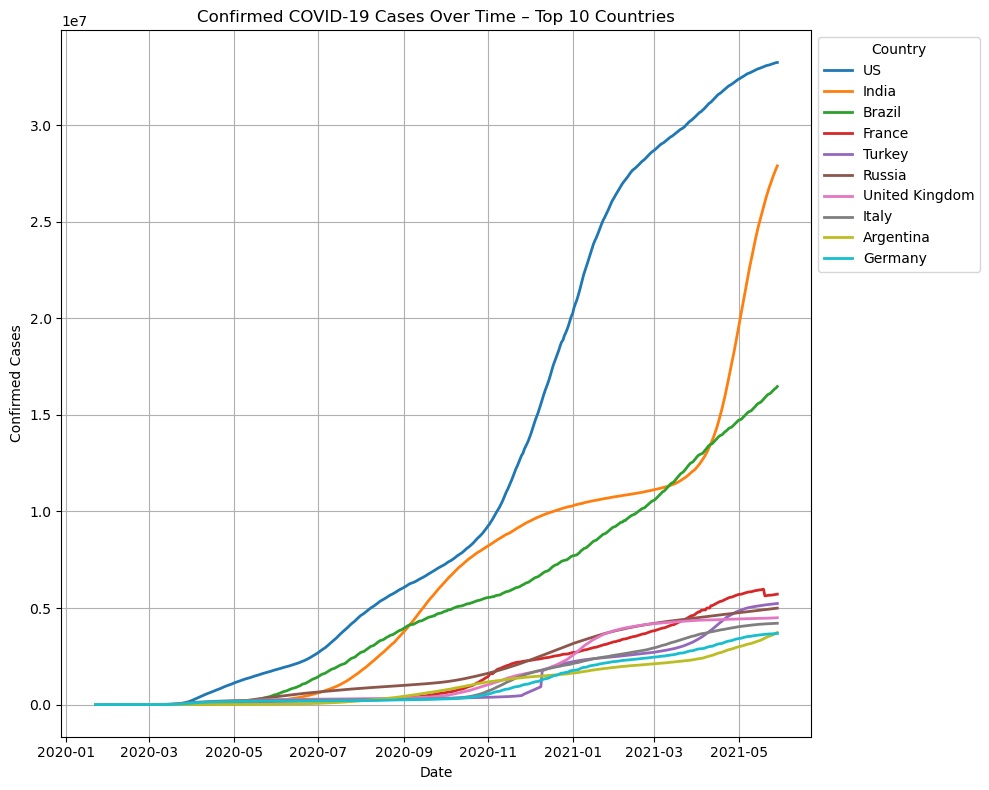

Top 10 countries:
['US', 'India', 'Brazil', 'France', 'Turkey', 'Russia', 'United Kingdom', 'Italy', 'Argentina', 'Germany']


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get date columns
date_cols = df_confirmed.columns[4:]

# Create proper date range
dates = pd.date_range(
    start="2020-01-22",
    periods=len(date_cols),
    freq="D"
)

# Convert case values to numeric
df_confirmed[date_cols] = df_confirmed[date_cols].apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

# Combine province/state rows to get country-level totals
country_cases = df_confirmed.groupby(
    "Country/Region"
)[date_cols].sum()

# Find the top 10 countries based on
# confirmed cases on the last date
top_countries = (
    country_cases.iloc[:, -1]
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Plot confirmed cases over time
plt.figure(figsize=(10, 8))

for country in top_countries:
    plt.plot(
        dates,
        country_cases.loc[country].values,
        label=country,
        linewidth=2
    )

# Add chart details
plt.title(
    "Confirmed COVID-19 Cases Over Time – Top 10 Countries"
)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.legend(
    title="Country",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()

# Display the top 10 countries
print("Top 10 countries:")
print(top_countries.tolist())

Q2.c. Generate plots of confirmed cases over time for China.

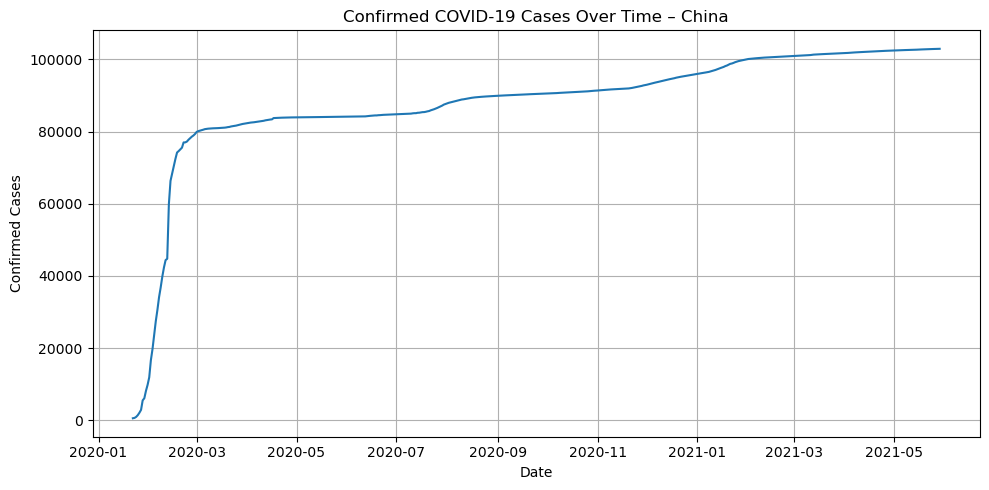

In [23]:
# Get date columns
date_cols = df_confirmed.columns[4:]

# Create proper date range
dates = pd.date_range(
    start="2020-01-22",
    periods=len(date_cols),
    freq="D"
)

# Convert case values to numeric
df_confirmed[date_cols] = df_confirmed[date_cols].apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

# select china
china_data = df_confirmed[ df_confirmed['Country/Region']== 'China'][date_cols].sum()

# Plot confirmed cases over time
plt.figure(figsize=(10, 5))

plt.plot(dates, china_data.values)

# Add chart details
plt.title(
    "Confirmed COVID-19 Cases Over Time – China"
)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()


Q3. Identify missing values and replace them using a suitable imputation method such as forward filling for time-series data.

In [28]:
#to display total missing values for all 3 scenarios-deaths, confirmed, recovered

print(f'Confirmed Case:\n',df_confirmed.isnull().sum())
print()
print(f'Death Case:\n',df_deaths.isnull().sum())
print()
print(f'Recovered Case:\n',df_recovered.isnull().sum())
print()

#there are missing values for Province/State for all 3 scenarios and we will be filling them ahead

Confirmed Case:
 Province/State    190
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
5/25/21             0
5/26/21             0
5/27/21             0
5/28/21             0
5/29/21             0
Length: 498, dtype: int64

Death Case:
 Province/State    190
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
5/25/21             0
5/26/21             0
5/27/21             0
5/28/21             0
5/29/21             0
Length: 498, dtype: int64

Recovered Case:
 Province/State    191
Country/Region      0
Lat                 1
Long                1
1/22/20             0
                 ... 
5/25/21             0
5/26/21             0
5/27/21             0
5/28/21             0
5/29/21             0
Length: 498, dtype: int64



In [33]:
#replacing missing values with forward fill for time-series data

# choose time series data for confirmed scenario
date_cols

print("Missing values before imputation:")
print(df_confirmed[date_cols].isnull().sum().sum())

#No imputation method is required for missing values 

#We can also check for all 3 scenarios

Missing values before imputation:
0


Q4. Data Cleaning and Preparation: Replace blank values in province column with “All Provinces”

In [23]:
df_confirmed['Province/State'] = df_confirmed['Province/State'].fillna('All Provinces')
print(df_confirmed['Province/State'].head())
print()


#to check if there are any missing values in 'Province/State' coln
print(f'Missing Values in Province/State Coln:',df_confirmed['Province/State'].isnull().sum())

0    All Provinces
1    All Provinces
2    All Provinces
3    All Provinces
4    All Provinces
Name: Province/State, dtype: object

Missing Values in Province/State Coln: 0


In [24]:
#confirmed
df_confirmed['Province/State'] = df_confirmed['Province/State'].fillna('All Provinces')
print(df_confirmed['Province/State'].head())
print()


#to check if there are any missing values in 'Province/State' coln
print(f'Missing Values in Province/State Coln:',df_confirmed['Province/State'].isnull().sum())

0    All Provinces
1    All Provinces
2    All Provinces
3    All Provinces
4    All Provinces
Name: Province/State, dtype: object

Missing Values in Province/State Coln: 0


In [25]:
#deaths

df_deaths['Province/State'] = df_deaths['Province/State'].fillna('All Provinces')
print(df_deaths['Province/State'].head())
print()


#to check if there are any missing values in 'Province/State' coln
print(f'Missing Values in Province/State Coln:',df_deaths['Province/State'].isnull().sum())

0    All Provinces
1    All Provinces
2    All Provinces
3    All Provinces
4    All Provinces
Name: Province/State, dtype: object

Missing Values in Province/State Coln: 0


Q5.a. Analyze the peak number of daily new cases in Germany, France, and Italy. Which country experienced the highest single-day surge, and when did it occur?

In [50]:
# Get date columns
date_cols = df_confirmed.columns[4:]

# Convert case values to numeric
df_confirmed[date_cols] = df_confirmed[date_cols].apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

# Combine provinces/states by country
country_data = df_confirmed.groupby(
    "Country/Region"
)[date_cols].sum()

# Countries to analyze
countries = ["Germany", "France", "Italy"]

for country in countries:
    cases = country_data.loc[country]

    #daily new cases 
    daily_cases = cases.diff()

    #single day surge(peak)
    peak_cases = daily_cases.max()
    peak_date = daily_cases.idxmax()

    print(country)
    print("Peak daily new cases:", int(peak_cases))
    print("Date:", peak_date)
    print()


Germany
Peak daily new cases: 49044
Date: 12/30/20

France
Peak daily new cases: 117900
Date: 2021-11-04 00:00:00

Italy
Peak daily new cases: 40902
Date: 11/13/20



Q5.b. Compare the recovery rates (recoveries/confirmed cases) between Canada and Australia as of December 31, 2020. Which country showed better 
management of the pandemic according to this metric?

In [54]:
# Date required
date = "12/31/20"

# Group confirmed cases by country
confirmed_data = df_confirmed.groupby(
    "Country/Region"
)[date].sum()
#print(confirmed_data)

# Group recovered cases by country
recovered_data = df_recovered.groupby(
    "Country/Region"
)[date].sum()
#print(recovered_data)

# Countries to compare
countries = ["Canada", "Australia"]

# Create comparison DataFrame
comparison = pd.DataFrame({
    "Confirmed Cases": confirmed_data.loc[countries],
    "Recoveries": recovered_data.loc[countries]
})

# Calculate recovery rate
comparison["Recovery Rate"] = (
    comparison["Recoveries"] /
    comparison["Confirmed Cases"]
) * 100

# Display results
print(comparison)


                Confirmed Cases  Recoveries  Recovery Rate
Country/Region                                            
Canada                   584409      493638      84.467898
Australia                 28425       22565      79.384345


Q5.c. What is the distribution of death rates (deaths/confirmed cases) among provinces in Canada? Identify the province with the highest and
lowest death rate as of the latest data point.

In [26]:
# Get date columns
date_cols = df_confirmed.columns[4:]

# Latest date
latest_date = date_cols[-1]

# Filter Canada
canada_confirmed = df_confirmed[
    df_confirmed["Country/Region"] == "Canada"
]

canada_deaths = df_deaths[
    df_deaths["Country/Region"] == "Canada"
]

# Group by province
confirmed = canada_confirmed.groupby(
    "Province/State"
)[latest_date].sum()

deaths = canada_deaths.groupby(
    "Province/State"
)[latest_date].sum()

# Create DataFrame
death_rate = pd.DataFrame({
    "Confirmed Cases": confirmed,
    "Deaths": deaths
})

# Calculate death rate
death_rate["Death Rate (%)"] = (
    death_rate["Deaths"] /
    death_rate["Confirmed Cases"]
) * 100

# Remove provinces with zero confirmed cases
death_rate = death_rate[
    death_rate["Confirmed Cases"] > 0
]

# Sort by death rate
death_rate = death_rate.sort_values("Death Rate (%)",ascending=False)

# Display results
print("Latest Date:", latest_date)
print("\nDeath Rate by Province:")
print(death_rate)

# Highest death rate
highest = death_rate.iloc[0]

print("\nHighest Death Rate:")
print(
    highest.name,
    "=", 
    round(highest["Death Rate (%)"], 2),
    "%"
)

# Lowest death rate
lowest = death_rate.iloc[-1]

print("\nLowest Death Rate:")
print(
    lowest.name,
    "=",
    round(lowest["Death Rate (%)"], 2),
    "%"
)


Latest Date: 5/29/21

Death Rate by Province:
                           Confirmed Cases  Deaths  Death Rate (%)
Province/State                                                    
Quebec                              369728   11125        3.008969
Yukon                                   84       2        2.380952
Manitoba                             50499    1045        2.069348
New Brunswick                         2191      43        1.962574
Ontario                             537138    8698        1.619323
Nova Scotia                           5530      84        1.518987
British Columbia                    143581    1692        1.178429
Saskatchewan                         46464     537        1.155733
Alberta                             226855    2214        0.975954
Nunavut                                648       4        0.617284
Newfoundland and Labrador             1302       6        0.460829
Grand Princess                          13       0        0.000000
Northwest Territ

Q6. a.Transform the ‘deaths’ dataset from wide format (where each column represents a date) tolong format where each row represents a single date and 
columns are now country names, ensuring that the date column is in datetime format. How would this transformation be executed?

In [7]:
# Convert wide format to long format first
df_long = df_deaths.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Deaths"
)

# Convert Date to datetime
df_long["Date"] = pd.to_datetime(df_long["Date"])

# Create Date as rows and countries as columns
df_country = df_long.pivot_table(
    index="Date",
    columns="Country/Region",
    values="Deaths",
    aggfunc="sum"
).reset_index()

print(df_country.head())

Country/Region       Date  Afghanistan  Albania  Algeria  Andorra  Angola  \
0              2020-01-02          0.0      0.0      0.0      0.0     0.0   
1              2020-01-03          0.0      0.0      0.0      0.0     0.0   
2              2020-01-04          4.0     15.0     58.0     14.0     2.0   
3              2020-01-05         68.0     31.0    453.0     43.0     2.0   
4              2020-01-06        266.0     33.0    661.0     51.0     4.0   

Country/Region  Antigua and Barbuda  Argentina  Armenia  Australia  ...  \
0                               0.0        0.0      0.0        0.0  ...   
1                               0.0        0.0      0.0        1.0  ...   
2                               0.0       28.0      4.0       20.0  ...   
3                               3.0      225.0     33.0       93.0  ...   
4                               3.0      556.0    139.0      102.0  ...   

Country/Region  United Kingdom  Uruguay  Uzbekistan  Vanuatu  Venezuela  \
0          

C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\2456633243.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long["Date"] = pd.to_datetime(df_long["Date"])


Q6.b.What is the total number of deaths reported per country up to the current date?

In [11]:
# Get the latest date column
latest_date = df_deaths.columns[-1]

# Calculate total deaths by country
total_deaths = (
    df_deaths.groupby("Country/Region")[latest_date]
    .sum()
    .sort_values(ascending=False)
    .head()
)

print("Latest Date:", latest_date)
print("\nTotal Deaths by Country:\n")
print(total_deaths)

Latest Date: 5/29/21

Total Deaths by Country:

Country/Region
US                594306
Brazil            461057
India             325972
Mexico            223455
United Kingdom    128037
Name: 5/29/21, dtype: int64


Q6.c.What are the top 5 countries with the highest average daily deaths?

In [18]:
# Get all date columns
date_columns = df_deaths.columns[4:]

# Convert wide format to long format
df_long = df_deaths.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    value_vars=date_columns,
    var_name="Date",
    value_name="Deaths"
)

# Convert Date to datetime
df_long["Date"] = pd.to_datetime(df_long["Date"])

# Combine provinces/states to get country-level cumulative deaths
country_deaths = (
    df_long.groupby(["Country/Region", "Date"])["Deaths"]
    .sum()
    .reset_index()
)

# Calculate daily deaths
country_deaths["Daily Deaths"] = (
    country_deaths.groupby("Country/Region")["Deaths"]
    .diff()
    .fillna(country_deaths["Deaths"])
)

# Calculate average daily deaths by country
average_daily_deaths = (
    country_deaths.groupby("Country/Region")["Daily Deaths"]
    .mean().round(2)
    .sort_values(ascending=False)
)

# Display top 5
print("Top 5 Countries with Highest Average Daily Deaths:")
print(average_daily_deaths.head(5))

Top 5 Countries with Highest Average Daily Deaths:
Country/Region
US                1182.07
Brazil             866.47
India              522.91
Mexico             444.51
United Kingdom     258.91
Name: Daily Deaths, dtype: float64


C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\2435697366.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long["Date"] = pd.to_datetime(df_long["Date"])


Q6.d.How have the total deaths evolved over time in the United States?

In [53]:
# Select United States
df_us = df_deaths[df_deaths["Country/Region"] == "US"]

# Get date columns
date_columns = df_deaths.columns[4:]

# Sum deaths for the US
us_deaths = df_us[date_columns].sum()

# Convert dates to datetime
us_deaths.index = pd.to_datetime(us_deaths.index)
us_deaths

C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\681659011.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us_deaths.index = pd.to_datetime(us_deaths.index)


2020-01-22         0.0
2020-01-23         0.0
2020-01-24         0.0
2020-01-25         0.0
2020-01-26         0.0
                ...   
2021-05-25    590941.0
2021-05-26    591950.0
2021-05-27    593288.0
2021-05-28    593963.0
2021-05-29    594306.0
Length: 494, dtype: float64

Q7. Data Merging
a. How would you merge the transformed datasets of confirmed cases, deaths, and recoveries on the ‘Country/Region’ and ‘Date’ columns to create comprehensive view of the pandemic's impact?

To answer this question, we will first have to transform all 3 datasets from wide to long format using melt()

In [57]:
# Get date columns
date_columns = df_confirmed.columns[4:]

# Transform confirmed cases
confirmed_long = df_confirmed.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    value_vars=date_columns,
    var_name="Date",
    value_name="Confirmed"
)
#print(f'confirmed_long',confirmed_long)

# Transform deaths
deaths_long = df_deaths.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    value_vars=date_columns,
    var_name="Date",
    value_name="Deaths"
)

# Transform recovered
recovered_long = df_recovered.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    value_vars=date_columns,
    var_name="Date",
    value_name="Recovered"
)

confirmed_long        Province/State      Country/Region        Lat        Long     Date  \
0       All Provinces         Afghanistan  33.939110   67.709953  1/22/20   
1       All Provinces             Albania  41.153300   20.168300  1/22/20   
2       All Provinces             Algeria  28.033900    1.659600  1/22/20   
3       All Provinces             Andorra  42.506300    1.521800  1/22/20   
4       All Provinces              Angola -11.202700   17.873900  1/22/20   
...               ...                 ...        ...         ...      ...   
136339  All Provinces             Vietnam  14.058324  108.277199  5/29/21   
136340  All Provinces  West Bank and Gaza  31.952200   35.233200  5/29/21   
136341  All Provinces               Yemen  15.552727   48.516388  5/29/21   
136342  All Provinces              Zambia -13.133897   27.849332  5/29/21   
136343  All Provinces            Zimbabwe -19.015438   29.154857  5/29/21   

        Confirmed  
0               0  
1               0  


In [58]:
#convert all date to datetime

confirmed_long["Date"] = pd.to_datetime(confirmed_long["Date"])
deaths_long["Date"] = pd.to_datetime(deaths_long["Date"])
recovered_long["Date"] = pd.to_datetime(recovered_long["Date"])

C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\1042472578.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  confirmed_long["Date"] = pd.to_datetime(confirmed_long["Date"])
C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\1042472578.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deaths_long["Date"] = pd.to_datetime(deaths_long["Date"])
C:\Users\Intel\AppData\Local\Temp\ipykernel_14040\1042472578.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  recovered_long["Date"] = pd.to_datetime(recovered_long["Date"])


In [59]:
#groupby country and date 

confirmed_country = (
    confirmed_long
    .groupby(["Country/Region", "Date"])["Confirmed"]
    .sum()
    .reset_index()
)

deaths_country = (
    deaths_long
    .groupby(["Country/Region", "Date"])["Deaths"]
    .sum()
    .reset_index()
)

recovered_country = (
    recovered_long
    .groupby(["Country/Region", "Date"])["Recovered"]
    .sum()
    .reset_index()
)

In [60]:
#merge 3 datasets
#we use how='outer'  because we want everything from the dataset as we dont want to miss any information

pandemic_data = pd.merge(
    confirmed_country,
    deaths_country,
    on=["Country/Region", "Date"],
    how="outer"
)

pandemic_data = pd.merge(
    pandemic_data,
    recovered_country,
    on=["Country/Region", "Date"],
    how="outer"
)

In [61]:
#fill missing values and sort

pandemic_data[["Confirmed", "Deaths", "Recovered"]] = (
    pandemic_data[["Confirmed", "Deaths", "Recovered"]]
    .fillna(0)
)

pandemic_data = pandemic_data.sort_values(
    ["Country/Region", "Date"]
).reset_index(drop=True)

print(pandemic_data.head())

  Country/Region       Date  Confirmed  Deaths  Recovered
0    Afghanistan 2020-01-02          0     0.0        0.0
1    Afghanistan 2020-01-03          1     0.0        0.0
2    Afghanistan 2020-01-04        197     4.0        5.0
3    Afghanistan 2020-01-05       2291    68.0      310.0
4    Afghanistan 2020-01-06      15753   266.0     1428.0


In [ ]:
# to get a better picture what is just done

df_confirmed ──melt──> confirmed_long ──┐
                                        │
df_deaths ─────melt──> deaths_long ─────┼──> Merge
                                        │
df_recovered ──melt──> recovered_long ──┘
                                        ↓
                              pandemic_data

Q7.b.Analyze the monthly sum of confirmed cases, deaths, and recoveries for countries tounderstand the progression of the pandemic. From the merged dataset

In [62]:
#check date column type 
print(pandemic_data['Date'].dtype)

datetime64[ns]


In [67]:

# Ensure data is sorted
pandemic_data = pandemic_data.sort_values(
    ["Country/Region", "Date"]
)

# Calculate daily changes
pandemic_data["Daily Confirmed"] = (
    pandemic_data.groupby("Country/Region")["Confirmed"]
    .diff()
    .fillna(pandemic_data["Confirmed"])
)

pandemic_data["Daily Deaths"] = (
    pandemic_data.groupby("Country/Region")["Deaths"]
    .diff()
    .fillna(pandemic_data["Deaths"])
)

pandemic_data["Daily Recovered"] = (
    pandemic_data.groupby("Country/Region")["Recovered"]
    .diff()
    .fillna(pandemic_data["Recovered"])
)

# Create month
pandemic_data["Month"] = pandemic_data["Date"].dt.to_period("M")

# Monthly totals
monthly_data = (
    pandemic_data
    .groupby(["Country/Region", "Month"])[
        ["Daily Confirmed", "Daily Deaths", "Daily Recovered"]
    ]
    .sum()
    .reset_index()
    .head(12)
)

print(monthly_data)

   Country/Region    Month  Daily Confirmed  Daily Deaths  Daily Recovered
0     Afghanistan  2020-01              0.0           0.0              0.0
1     Afghanistan  2020-02              1.0           0.0              0.0
2     Afghanistan  2020-03            174.0           4.0              5.0
3     Afghanistan  2020-04           1952.0          60.0            255.0
4     Afghanistan  2020-05          13081.0         194.0           1068.0
5     Afghanistan  2020-06          16299.0         494.0          12803.0
6     Afghanistan  2020-07           5158.0         532.0          11378.0
7     Afghanistan  2020-08           1494.0         119.0           3580.0
8     Afghanistan  2020-09           1109.0          57.0           3700.0
9     Afghanistan  2020-10           2157.0          78.0           1532.0
10    Afghanistan  2020-11           4849.0         257.0           2510.0
11    Afghanistan  2020-12           5252.0         396.0           4896.0


Q7.c. Redo the analysis in last question for United States, Italy and Brazil.

In [68]:
#create for required countries

selected_countries = ['United States', 'Italy','Brazil']

#calculate monthly total
monthly_data = (
    pandemic_data[
        pandemic_data["Country/Region"].isin(selected_countries)
    ]
    .groupby(["Country/Region", "Month"])[
        ["Daily Confirmed", "Daily Deaths", "Daily Recovered"]
    ]
    .sum()
    .reset_index()
)

print(monthly_data)

   Country/Region    Month  Daily Confirmed  Daily Deaths  Daily Recovered
0          Brazil  2020-01              0.0           0.0              0.0
1          Brazil  2020-02              2.0           0.0              0.0
2          Brazil  2020-03           5715.0         201.0            127.0
3          Brazil  2020-04          81470.0        5805.0          35808.0
4          Brazil  2020-05         427662.0       23308.0         170620.0
5          Brazil  2020-06         887192.0       30280.0         581763.0
6          Brazil  2020-07        1260444.0       32881.0        1220536.0
7          Brazil  2020-08        1245787.0       28906.0        1259737.0
8          Brazil  2020-09         902663.0       22571.0        1006183.0
9          Brazil  2020-10         724670.0       15932.0         730387.0
10         Brazil  2020-11         800273.0       13236.0         592641.0
11         Brazil  2020-12        1340095.0       21829.0        1251042.0
12         Brazil  2021-0

Q8.a.For the combined dataset, identify the three countries with the highest average death rates(deaths/confirmed cases) throughout 2020. What might this indicate about the pandemic's impact in these countries?

In [69]:
pandemic_data.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Month,Daily Confirmed,Daily Deaths,Daily Recovered
0,Afghanistan,2020-01-02,0,0.0,0.0,2020-01,0.0,0.0,0.0
1,Afghanistan,2020-01-03,1,0.0,0.0,2020-01,1.0,0.0,0.0
2,Afghanistan,2020-01-04,197,4.0,5.0,2020-01,196.0,4.0,5.0
3,Afghanistan,2020-01-05,2291,68.0,310.0,2020-01,2094.0,64.0,305.0
4,Afghanistan,2020-01-06,15753,266.0,1428.0,2020-01,13462.0,198.0,1118.0


In [77]:
#Select date 2020
data_2020 = pandemic_data[
    pandemic_data['Date'].dt.year == 2020
    ].copy()

#calculate death rate 
data_2020['Death Rate(%)'] = (data_2020['Deaths']/data_2020['Confirmed'])*100

#date_2020

# Remove rows where confirmed cases are 0
data_2020 = data_2020[
    data_2020["Confirmed"] > 0 ]

#Calculate average death rate by each country 

avg_death_rate = (
    data_2020
    .groupby('Country/Region')['Death Rate(%)']
    .mean()
    .sort_values(ascending = False)
)

# Top 3 countries
top_3 = avg_death_rate.head(3)

print("Top 3 Countries with Highest Average Death Rate in 2020:\n")
print(top_3)

Top 3 Countries with Highest Average Death Rate in 2020:

Country/Region
Yemen         24.953163
MS Zaandam    21.903624
Sudan         10.370637
Name: Death Rate(%), dtype: float64


Q8.b. Using the merged dataset, compare the total number of recoveries to the total number of deaths in South Africa. What can this tell us about the outcomes of COVID-19 cases in the country?

In [81]:
#select south africa
south_africa = pandemic_data[
    pandemic_data['Country/Region'] == 'South Africa'
    ].copy()
#print(south_africa)

#get the latest date
latest_date  = south_africa['Date'].max()

# Get latest values
latest_data = south_africa[
    south_africa["Date"] == latest_date
].iloc[0]

#print(latest_data)

total_recovered = latest_data["Recovered"]
total_deaths = latest_data["Deaths"]

print("Latest Date:", latest_date)
print("Total Recoveries:", int(total_recovered))
print("Total Deaths:", int(total_deaths))

# Compare recoveries to deaths
ratio = total_recovered / total_deaths

print("Recovery-to-Death Ratio:", round(ratio, 2))

Latest Date: 2021-12-05 00:00:00
Total Recoveries: 1519734
Total Deaths: 54968
Recovery-to-Death Ratio: 27.65


Interpretation - In South Africa, total recoveries were considerably higher than total deaths. This indicates that among the reported COVID-19 outcomes, recovery was much more common than death. However, the recovery-to-death ratio should be interpreted cautiously because reporting practices and delays can affect cumulative recovery and death figures.

Q8.c. Analyze the ratio of recoveries to confirmed cases for the United States on a monthly basis from March 2020 to May 2021. Which month experienced the highest recovery ratio, and what could be the potential reasons?

In [82]:
# Select United States and required period
us_data = pandemic_data[
    (pandemic_data["Country/Region"] == "US") &
    (pandemic_data["Date"] >= "2020-03-01") &
    (pandemic_data["Date"] <= "2021-05-31")
].copy()

# Create Month column
us_data["Month"] = us_data["Date"].dt.to_period("M")

# Calculate monthly totals
monthly_us = (
    us_data
    .groupby("Month")[["Confirmed", "Recovered"]]
    .sum()
    .reset_index()
)

# Calculate recovery ratio
monthly_us["Recovery Ratio (%)"] = (
    monthly_us["Recovered"] /
    monthly_us["Confirmed"]
) * 100

# Display result
print(monthly_us)

      Month  Confirmed    Recovered  Recovery Ratio (%)
0   2020-03   49251512   17266040.0           35.056873
1   2020-04   63906892   19024548.0           29.769165
2   2020-05   79852288   24126537.0           30.213958
3   2020-06   91706926   29321196.0           31.972717
4   2020-07  126004651   41339627.0           32.808017
5   2020-08  158562744   56051131.0           35.349496
6   2020-09  175576873   66181707.0           37.693864
7   2020-10  213270323   82616511.0           38.737931
8   2020-11  273831307  101592133.0           37.100262
9   2020-12  401432296   25708091.0            6.404091
10  2021-01  609930951          0.0            0.000000
11  2021-02  589142237          0.0            0.000000
12  2021-03  707605918          0.0            0.000000
13  2021-04  713557698          0.0            0.000000
14  2021-05  702550516          0.0            0.000000


In [83]:
# month with the highest recovery ratio

highest_month = monthly_us.loc[
    monthly_us["Recovery Ratio (%)"].idxmax()
]

print("Month with Highest Recovery Ratio:")
print(highest_month)

Month with Highest Recovery Ratio:
Month                    2020-10
Confirmed              213270323
Recovered             82616511.0
Recovery Ratio (%)     38.737931
Name: 7, dtype: object


Interpretation - The recovery ratio in the United States increased from March 2020 and reached its highest level in October 2020, at approximately 38.74%. This may indicate improved recovery reporting, increasing numbers of patients completing their recovery period, and improvements in clinical management.